In [139]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [140]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Data Preparation

In [141]:
df = pd.read_csv("HouseSale.csv")
df

,_________,____________,____________.1,________ (__),zone Rating,_______ (USD)
0,50.3,5,2,8,1,206042
1,50.9,2,1,21,1,179398
2,53.4,3,1,10,1,187509
3,56.4,5,3,8,1,242866
4,56.6,1,3,16,1,158455
...,...,...,...,...,...,...
356,497.4,5,2,26,5,1107045
357,499.5,3,2,19,5,1092027
358,499.6,1,3,12,5,1102534
359,499.6,5,1,23,5,1070454


In [142]:
df.shape

(361, 6)

In [143]:
df.isna().sum()

_________         0
____________      0
____________.1    0
________ (__)     0
zone Rating       0
_______ (USD)     0
dtype: int64

In [144]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   _________       361 non-null    str  
 1   ____________    361 non-null    str  
 2   ____________.1  361 non-null    str  
 3   ________ (__)   361 non-null    str  
 4   zone Rating     361 non-null    str  
 5   _______ (USD)   361 non-null    str  
dtypes: str(6)
memory usage: 17.1 KB


In [145]:
df = df.apply(pd.to_numeric, errors='coerce')

In [146]:
df.columns = [
    'sq_meters',   # ตารางเมตร
    'bedrooms',    # จำนวนห้องนอน
    'bathrooms',   # จำนวนห้องน้ำ
    'house_age',   # อายุบ้าน (ปี)
    'zone_rating', # zone Rating
    'price_usd'    # ราคาขาย (USD)
]

print(df.head())

   sq_meters  bedrooms  bathrooms  house_age  zone_rating  price_usd
0       50.3       5.0        2.0        8.0          1.0   206042.0
1       50.9       2.0        1.0       21.0          1.0   179398.0
2       53.4       3.0        1.0       10.0          1.0   187509.0
3       56.4       5.0        3.0        8.0          1.0   242866.0
4       56.6       1.0        3.0       16.0          1.0   158455.0


In [147]:
avg_max = df.agg(['mean', 'max'])
print(avg_max)

       sq_meters  bedrooms  bathrooms  house_age  zone_rating    price_usd
mean  277.084444  2.961111   1.969444  16.647222     3.627778   631059.675
max   499.600000  5.000000   3.000000  29.000000     5.000000  1108237.000


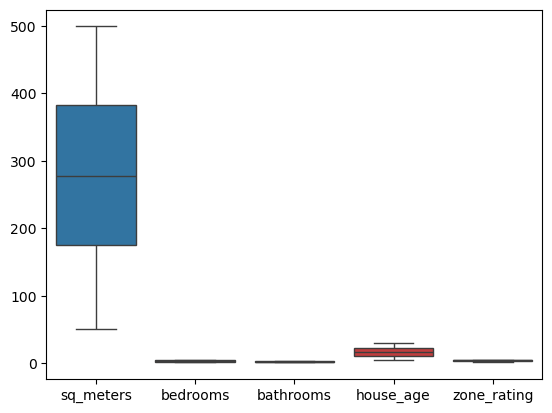

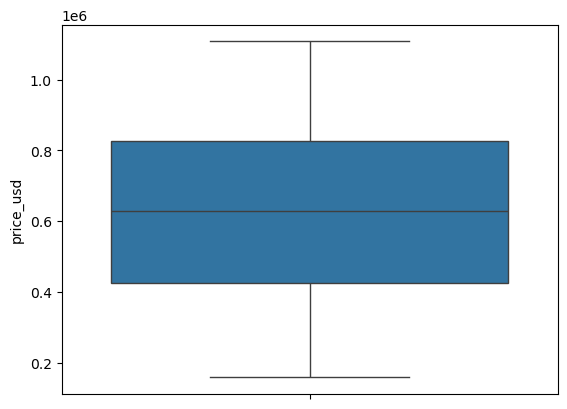

In [148]:
sns.boxplot(data=df.iloc[:, 0:5])
plt.show()

sns.boxplot(data=df.iloc[:, -1])
plt.show()

<Axes: >

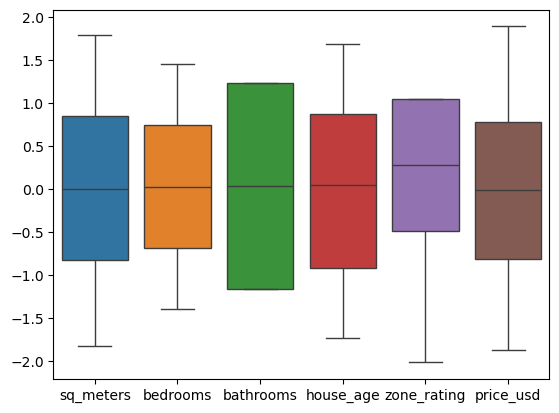

In [149]:
df_numeric = df.select_dtypes(include=['number']).drop(columns=['_______(USD)'], errors='ignore')

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)
df_scaled = pd.DataFrame(scaled_data, columns=df_numeric.columns)

sns.boxplot(data=df_scaled)

In [150]:
df_scaled = df_scaled.fillna(df_scaled.mean())

In [151]:
X = df_scaled.iloc[:, :-1]
y = df_scaled.iloc[:, -1]

In [152]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

In [153]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [154]:
model = Lasso(alpha=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [155]:
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")

R2 Score: 0.9745479310486252
Mean Squared Error: 0.0277452895397424


# Validation

In [156]:
from sklearn.model_selection import train_test_split

In [157]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 216
Validation size: 72
Test size: 73


In [158]:
y_pred_val = model.predict(X_val)
score = model

In [159]:
print(f"Training Score:   {model.score(X_train, y_train):.4f}")
print(f"Validation Score: {model.score(X_val, y_val):.4f}")

Training Score:   0.9750
Validation Score: 0.9759


In [160]:
importance = pd.Series(model.coef_, index=X.columns)
print("Feature Importance:\n", importance.sort_values(ascending=False))

Feature Importance:
 sq_meters      0.873715
zone_rating    0.014805
bedrooms       0.000000
bathrooms      0.000000
house_age     -0.000000
dtype: float64


# Measure the model

In [161]:
y_pred = model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
print(f"R2 Score: {r2_score(y_val, y_pred)}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

R2 Score: 0.9759158489265868
MAE: 0.13
MSE: 0.03
RMSE: 0.16


# Try dropping important features

In [162]:
X_train_new = X_train.drop(X_train.columns[0], axis=1)
X_val_new = X_val.drop(X_train.columns[0], axis=1)

model.fit(X_train_new, y_train)
print(f"New Validation Score: {model.score(X_val_new, y_val):.4f}")

New Validation Score: 0.8555


In [163]:
importance = pd.Series(model.coef_, index=X_train_new.columns)
print("Feature Importance:\n", importance.sort_values(ascending=False))

Feature Importance:
 zone_rating    0.812021
bedrooms       0.000000
bathrooms     -0.000000
house_age     -0.000000
dtype: float64


In [164]:
X_train_new = X_train_new.drop(["zone_rating"], axis=1)
X_val_new = X_val_new.drop(["zone_rating"], axis=1)

model.fit(X_train_new, y_train)
print(f"New Validation Score: {model.score(X_val_new, y_val):.4f}")

New Validation Score: -0.0038


In [165]:
importance = pd.Series(model.coef_, index=X_train_new.columns)
print("Feature Importance:\n", importance.sort_values(ascending=False))

Feature Importance:
 bedrooms     0.0
bathrooms    0.0
house_age    0.0
dtype: float64


# Further measurement

In [166]:
y_pred = model.predict(X_val_new)
mae = mean_absolute_error(y_val, y_pred)
print(f"MAE: {mae:.2f}")

MAE: 0.90


In [167]:
mse = mean_squared_error(y_val, y_pred)
print(f"MSE: {mse:.2f}")

MSE: 1.11


In [168]:
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

RMSE: 1.05
